In [6]:
# =========================
# IMPORT
# =========================
import importlib
import aml_tools
importlib.reload(aml_tools)

from aml_tools import aml_data_read, aml_remove_nan, aml_oxygen_correction



# =========================
# LOAD DATA
# =========================
fname = '/Users/ej/Desktop/Applied Ocean Observation Technologies/AML/AML Data/aml_log_2026-06-09_07-26-53.aml'

h, V, D = aml_data_read(fname)


# =========================
# CHECK WHAT YOU HAVE
# =========================
print("Number of variables:", len(D))


# List all variables
for i, d in enumerate(D):
    print(i, d['name'])

Number of variables: 20
0 Time
1 Cond
2 ADC
3 TempCT
4 ADC
5 Pressure
6 ADC
7 DO
8 TempDO
9 DOM
10 ADC
11 Chloro-blue
12 ADC
13 Turbidity
14 ADC
15 analog
16 ADC
17 Salinity
18 Density
19 Depth


In [7]:
# =========================
# SELECT VARIABLES
# =========================
idepth  = 19
idox    = 7
itempCT = 3
itempDO = 8
isalt   = 17
ipress  = 5
idens   = 18
idom    = 9
ichla   = 11
iturb   = 13

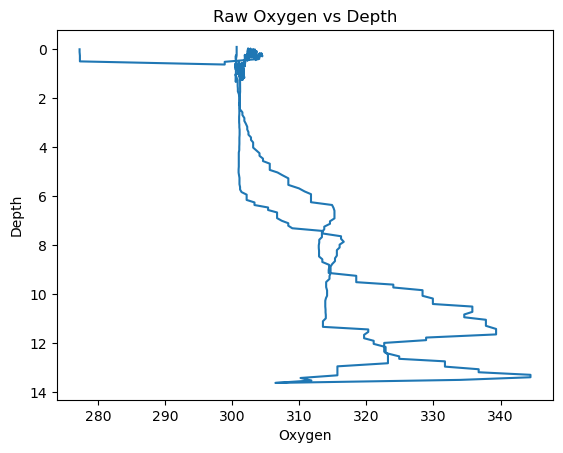

In [8]:

import matplotlib.pyplot as plt

plt.figure()
plt.plot(D[idox]['dat'], D[idepth]['dat'])
plt.gca().invert_yaxis()

plt.xlabel("Oxygen")
plt.ylabel("Depth")
plt.title("Raw Oxygen vs Depth")

plt.show()


In [9]:

from scipy.ndimage import uniform_filter1d
import numpy as np

In [10]:
depth = D[idepth]['dat']

# calculate how depth changes
grad = np.gradient(depth)

# smooth it (important!)
smooth_grad = uniform_filter1d(grad, size=300)

# create mask: shallow OR going upward
ii = (depth < 1.5) | (smooth_grad < 0)

In [11]:

for idx in [idepth, idox, itempCT, isalt]:
    D[idx]['dat'][ii] = np.nan

In [12]:
from aml_tools import aml_remove_nan

D = aml_remove_nan(D, idepth)

In [13]:
print(len(D[idepth]['dat']))

71


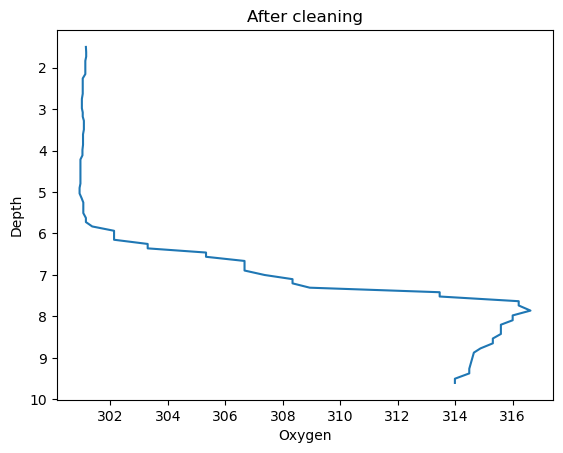

In [14]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(D[idox]['dat'], D[idepth]['dat'])

plt.gca().invert_yaxis()
plt.xlabel("Oxygen")
plt.ylabel("Depth")

plt.title("After cleaning")

plt.show()


In [15]:
from aml_tools import aml_oxygen_correction
D = aml_oxygen_correction(D, idox, itempDO, ipress, isalt, idens)

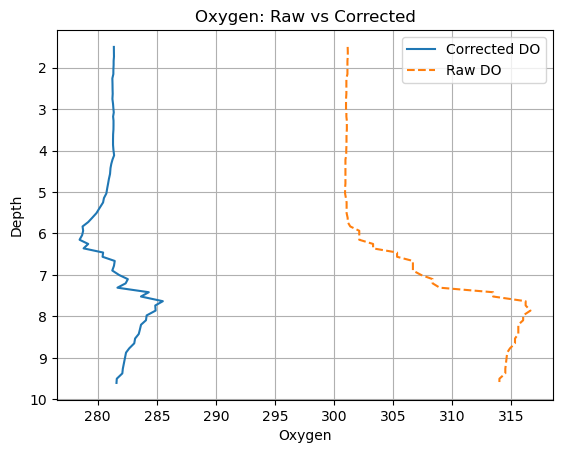

In [16]:
import matplotlib.pyplot as plt

plt.figure()

# corrected
plt.plot(D[idox]['dat'], D[idepth]['dat'], label='Corrected DO')

# original
plt.plot(D[idox]['datc'], D[idepth]['dat'], '--', label='Raw DO')

plt.gca().invert_yaxis()

plt.xlabel("Oxygen")
plt.ylabel("Depth")
plt.title("Oxygen: Raw vs Corrected")

plt.legend()
plt.grid()

plt.show()


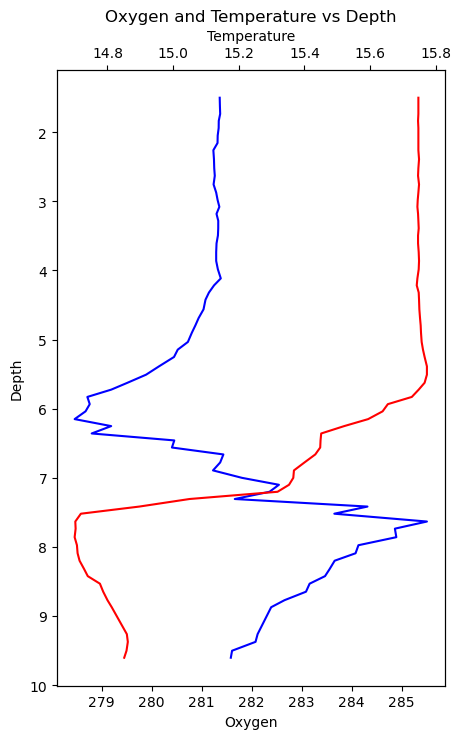

In [18]:
fig, ax1 = plt.subplots(figsize=(5, 8))

# Oxygen (left axis)
ax1.plot(D[idox]['dat'], D[idepth]['dat'], 'b-', label='Oxygen')
ax1.set_xlabel('Oxygen')
ax1.set_ylabel('Depth')
ax1.invert_yaxis()

# Second axis for temperature
ax2 = ax1.twiny()
ax2.plot(D[itempCT]['dat'], D[idepth]['dat'], 'r-', label='Temperature')
ax2.set_xlabel('Temperature')

plt.title("Oxygen and Temperature vs Depth")

plt.show()

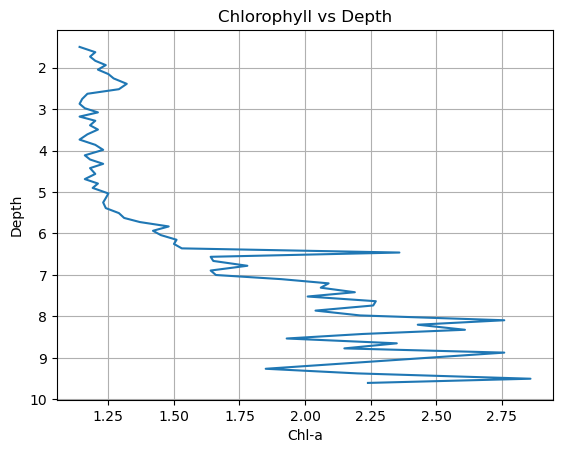

In [19]:
plt.figure()

plt.plot(D[ichla]['dat'], D[idepth]['dat'])
plt.gca().invert_yaxis()

plt.xlabel("Chl-a")
plt.ylabel("Depth")
plt.title("Chlorophyll vs Depth")

plt.grid()
plt.show()

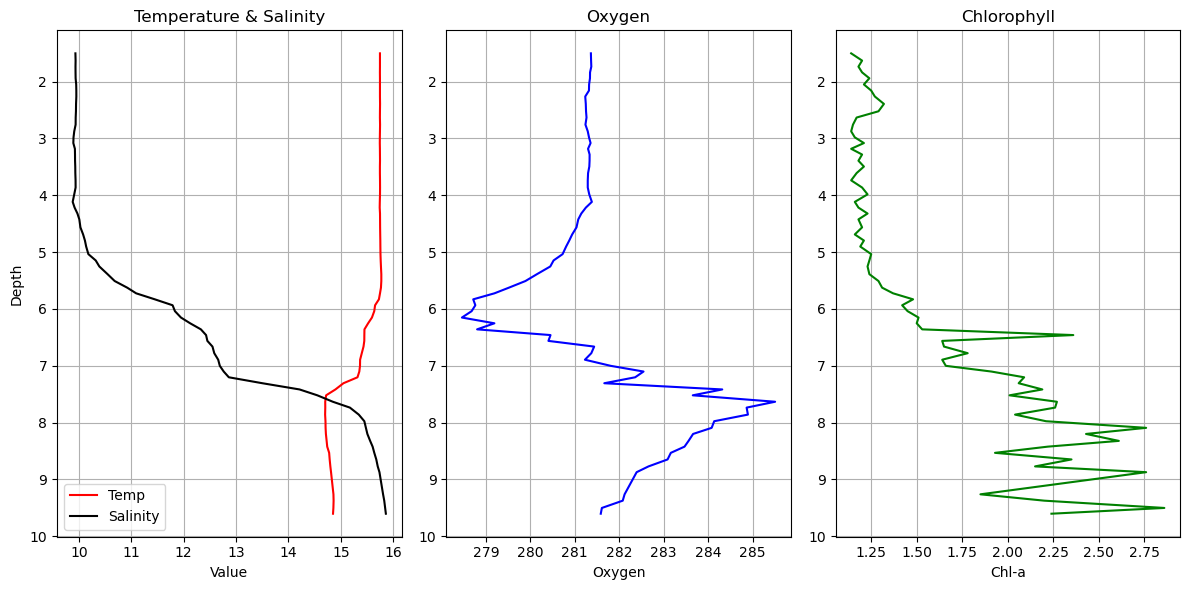

In [20]:
plt.figure(figsize=(12, 6))

# -------- Panel 1: Temperature + Salinity --------
plt.subplot(1, 3, 1)

plt.plot(D[itempCT]['dat'], D[idepth]['dat'], 'r-', label='Temp')
plt.plot(D[isalt]['dat'], D[idepth]['dat'], 'k-', label='Salinity')

plt.gca().invert_yaxis()
plt.xlabel('Value')
plt.ylabel('Depth')
plt.title('Temperature & Salinity')

plt.legend()
plt.grid()


# -------- Panel 2: Oxygen --------
plt.subplot(1, 3, 2)

plt.plot(D[idox]['dat'], D[idepth]['dat'], 'b-')

plt.gca().invert_yaxis()
plt.xlabel('Oxygen')
plt.title('Oxygen')

plt.grid()


# -------- Panel 3: Chlorophyll --------
plt.subplot(1, 3, 3)

plt.plot(D[ichla]['dat'], D[idepth]['dat'], 'g-')

plt.gca().invert_yaxis()
plt.xlabel('Chl-a')
plt.title('Chlorophyll')

plt.grid()


plt.tight_layout()
plt.show()

In [21]:
import os

folder = '/Users/ej/Desktop/Applied Ocean Observation Technologies/AML/AML Data'

all_files = [f for f in os.listdir(folder) if f.endswith('.aml')]

print(all_files)


['aml_log_2026-06-10_12-50-12.aml', 'aml_log_2026-06-10_10-25-21.aml', 'aml_log_2026-06-09_08-12-48.aml', 'aml_log_2026-06-09_10-26-13.aml', 'aml_log_2026-06-11_07-18-21.aml', 'aml_log_2026-06-10_10-58-31.aml', 'aml_log_2026-06-09_07-26-53.aml', 'aml_log_2026-06-10_09-15-08.aml', 'aml_log_2026-06-10_09-48-51.aml', 'aml_log_2026-06-09_10-48-25.aml', 'aml_log_2026-06-09_12-36-36.aml', 'aml_log_2026-06-10_12-24-57.aml', 'aml_log_2026-06-10_08-54-20.aml', 'aml_log_2026-06-09_12-06-56.aml', 'aml_log_2026-06-09_11-17-20.aml', 'aml_log_2026-06-11_11-26-55.aml', 'aml_log_2026-06-11_07-57-07.aml', 'aml_log_2026-06-10_10-09-28.aml', 'aml_log_2026-06-11_11-44-06.aml', 'aml_log_2026-06-09_09-08-08.aml', 'aml_log_2026-06-10_13-05-45.aml', 'aml_log_2026-06-09_10-20-51.aml', 'aml_log_2026-06-09_08-36-40.aml', 'aml_log_2026-06-10_07-41-28.aml', 'aml_log_2026-06-11_12-05-33.aml', 'aml_log_2026-06-11_09-20-32.aml', 'aml_log_2026-06-10_11-17-15.aml', 'aml_log_2026-06-10_07-46-31.aml']


In [22]:
from datetime import datetime

tuesday_files = []

for f in all_files:
    
    # extract date string from filename
    date_str = f.split('_')[2]   # gives '2026-06-09'
    
    # convert to datetime
    date_obj = datetime.strptime(date_str, "%Y-%m-%d")
    
    # check if Tuesday (Tuesday = 1)
    if date_obj.weekday() == 1:
        tuesday_files.append(f)

print("Tuesday files:", tuesday_files)

Tuesday files: ['aml_log_2026-06-09_08-12-48.aml', 'aml_log_2026-06-09_10-26-13.aml', 'aml_log_2026-06-09_07-26-53.aml', 'aml_log_2026-06-09_10-48-25.aml', 'aml_log_2026-06-09_12-36-36.aml', 'aml_log_2026-06-09_12-06-56.aml', 'aml_log_2026-06-09_11-17-20.aml', 'aml_log_2026-06-09_09-08-08.aml', 'aml_log_2026-06-09_10-20-51.aml', 'aml_log_2026-06-09_08-36-40.aml']


In [23]:
thursday_files = []

for f in all_files:
    
    date_str = f.split('_')[2]
    date_obj = datetime.strptime(date_str, "%Y-%m-%d")
    
    if date_obj.weekday() == 3:  # Thursday
        thursday_files.append(f)

print("Thursday files:", thursday_files)

Thursday files: ['aml_log_2026-06-11_07-18-21.aml', 'aml_log_2026-06-11_11-26-55.aml', 'aml_log_2026-06-11_07-57-07.aml', 'aml_log_2026-06-11_11-44-06.aml', 'aml_log_2026-06-11_12-05-33.aml', 'aml_log_2026-06-11_09-20-32.aml']


In [24]:
main_files = all_files

In [25]:
import numpy as np
from scipy.ndimage import uniform_filter1d

def process_ctd_full(fname):
    
    h, V, D = aml_data_read(fname)
    
    idepth  = 19
    idox    = 7
    itempCT = 3
    itempDO = 8
    isalt   = 17
    ipress  = 5
    idens   = 18
    ichla   = 11

    depth = D[idepth]['dat']
    grad = np.gradient(depth)
    smooth_grad = uniform_filter1d(grad, size=300)

    ii = (depth < 1.0) | (smooth_grad < 0)

    for idx in [idepth, idox, itempCT, isalt, itempDO, ipress, idens, ichla]:
        D[idx]['dat'][ii] = np.nan

    D = aml_remove_nan(D, idepth)
    D = aml_oxygen_correction(D, idox, itempDO, ipress, isalt, idens)

    return D

In [26]:
all_profiles = []

for f in main_files:
    
    fname = folder + '/' + f
    D = process_ctd_full(fname)
    
    all_profiles.append(D)

In [27]:
depth_grid = np.linspace(0, 20, 200)

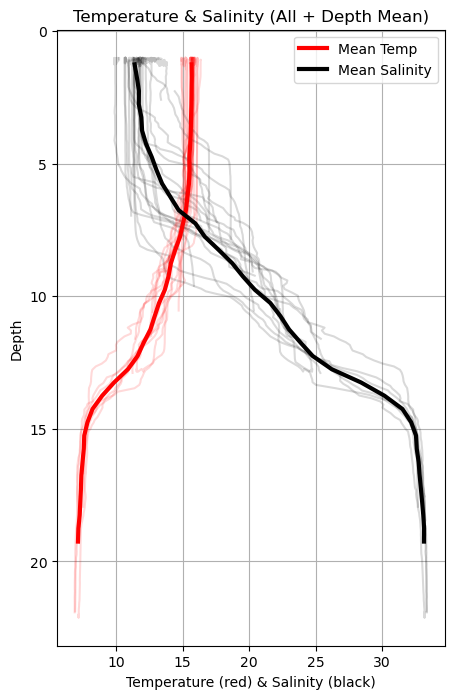

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# define depth bins
depth_bins = np.arange(0, 20, 0.5)

mean_temp = []
mean_salt = []
depth_centers = []

for i in range(len(depth_bins)-1):
    
    zmin = depth_bins[i]
    zmax = depth_bins[i+1]
    
    temp_values = []
    salt_values = []
    
    for D in all_profiles:
        
        depth = D[idepth]['dat']
        temp = D[itempCT]['dat']
        salt = D[isalt]['dat']
        
        mask = (depth >= zmin) & (depth < zmax)
        
        temp_values.extend(temp[mask])
        salt_values.extend(salt[mask])
    
    # only keep bins with data
    if len(temp_values) > 0 and len(salt_values) > 0:
        mean_temp.append(np.mean(temp_values))
        mean_salt.append(np.mean(salt_values))
        depth_centers.append((zmin + zmax)/2)

# ---- PLOT ----
plt.figure(figsize=(5,8))

# all profiles (light)
for D in all_profiles:
    plt.plot(D[itempCT]['dat'], D[idepth]['dat'], 'r-', alpha=0.15)
    plt.plot(D[isalt]['dat'], D[idepth]['dat'], 'k-', alpha=0.15)

# averaged profiles ✅
plt.plot(mean_temp, depth_centers, 'r-', linewidth=3, label='Mean Temp')
plt.plot(mean_salt, depth_centers, 'k-', linewidth=3, label='Mean Salinity')

plt.gca().invert_yaxis()
plt.xlabel("Temperature (red) & Salinity (black)")
plt.ylabel("Depth")
plt.title("Temperature & Salinity (All + Depth Mean)")

plt.legend()
plt.grid()
plt.show()

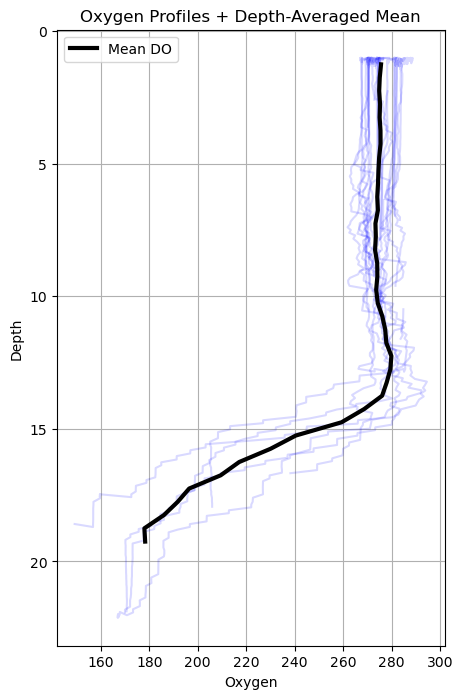

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# define depth bins (VERY important)
depth_bins = np.arange(0, 20, 0.5)

mean_do = []
median_do = []
depth_centers = []

# loop over bins
for i in range(len(depth_bins)-1):
    
    zmin = depth_bins[i]
    zmax = depth_bins[i+1]
    
    values = []
    
    # collect all values from ALL profiles within this depth range
    for D in all_profiles:
        
        depth = D[idepth]['dat']
        do = D[idox]['dat']
        
        mask = (depth >= zmin) & (depth < zmax)
        
        values.extend(do[mask])
    
    # compute stats
    if len(values) > 0:
        mean_do.append(np.mean(values))
        median_do.append(np.median(values))
        depth_centers.append((zmin + zmax)/2)

# ---- plotting ----
plt.figure(figsize=(5,8))

# plot all profiles (light)
for D in all_profiles:
    plt.plot(D[idox]['dat'], D[idepth]['dat'], 'b-', alpha=0.15)

# plot average profile ✅
plt.plot(mean_do, depth_centers, 'k-', linewidth=3, label='Mean DO')

# OPTIONAL: median instead
# plt.plot(median_do, depth_centers, 'r-', linewidth=2, label='Median DO')

plt.gca().invert_yaxis()
plt.xlabel("Oxygen")
plt.ylabel("Depth")
plt.title("Oxygen Profiles + Depth-Averaged Mean")

plt.legend()
plt.grid()
plt.show()

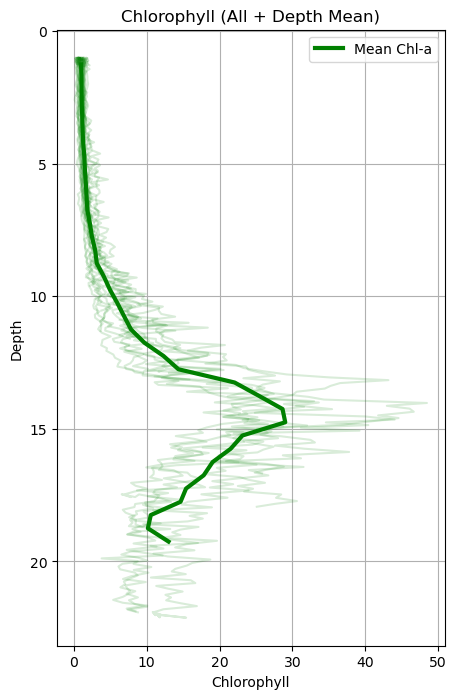

In [30]:
mean_chl = []
depth_centers = []

for i in range(len(depth_bins)-1):
    
    zmin = depth_bins[i]
    zmax = depth_bins[i+1]
    
    chl_values = []
    
    for D in all_profiles:
        
        depth = D[idepth]['dat']
        chl = D[ichla]['dat']
        
        mask = (depth >= zmin) & (depth < zmax)
        
        chl_values.extend(chl[mask])
    
    if len(chl_values) > 0:
        mean_chl.append(np.mean(chl_values))
        depth_centers.append((zmin + zmax)/2)

# ---- PLOT ----
plt.figure(figsize=(5,8))

# all profiles
for D in all_profiles:
    plt.plot(D[ichla]['dat'], D[idepth]['dat'], 'g-', alpha=0.15)

# averaged profile ✅
plt.plot(mean_chl, depth_centers, 'g-', linewidth=3, label='Mean Chl-a')

plt.gca().invert_yaxis()
plt.xlabel("Chlorophyll")
plt.ylabel("Depth")
plt.title("Chlorophyll (All + Depth Mean)")

plt.legend()
plt.grid()
plt.show()


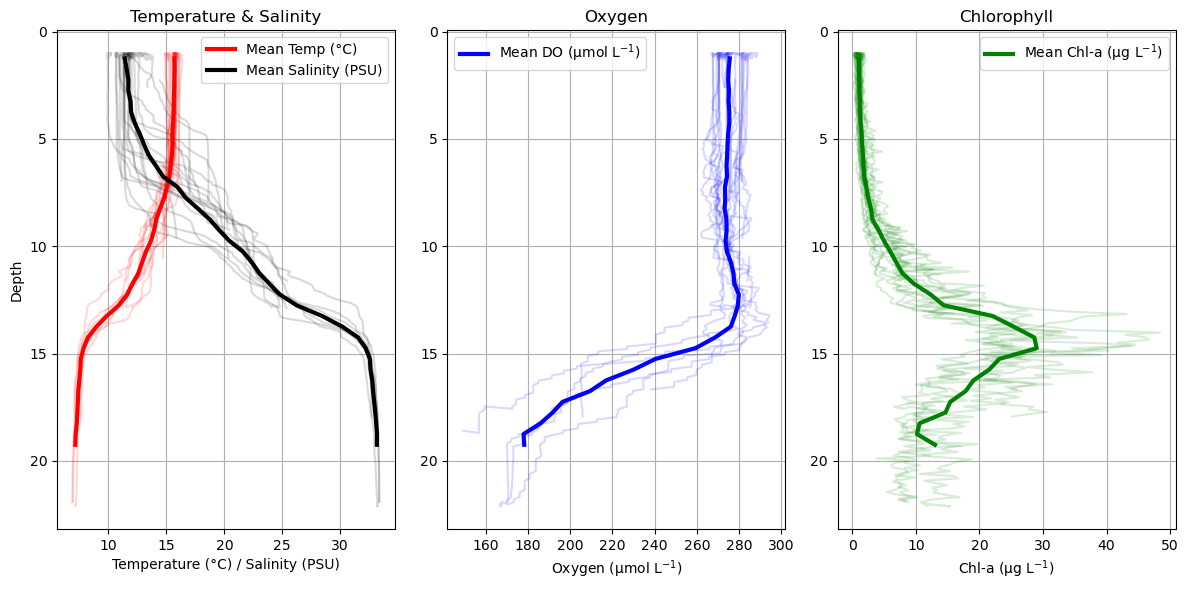

In [42]:
import numpy as np
import matplotlib.pyplot as plt

# depth bins for averaging
depth_bins = np.arange(0, 20, 0.5)

# store averages
depth_centers = []

mean_temp = []
mean_salt = []
mean_do = []
mean_chl = []

# ---- compute depth-based averages ----
for i in range(len(depth_bins)-1):
    
    zmin = depth_bins[i]
    zmax = depth_bins[i+1]
    
    temp_vals = []
    salt_vals = []
    do_vals = []
    chl_vals = []
    
    for D in all_profiles:
        
        depth = D[idepth]['dat']
        
        mask = (depth >= zmin) & (depth < zmax)
        
        temp_vals.extend(D[itempCT]['dat'][mask])
        salt_vals.extend(D[isalt]['dat'][mask])
        do_vals.extend(D[idox]['dat'][mask])
        chl_vals.extend(D[ichla]['dat'][mask])
    
    if len(temp_vals) > 0:
        depth_centers.append((zmin + zmax)/2)
        mean_temp.append(np.mean(temp_vals))
        mean_salt.append(np.mean(salt_vals))
        mean_do.append(np.mean(do_vals))
        mean_chl.append(np.mean(chl_vals))


# =========================
# PLOTTING (same style as yours)
# =========================

plt.figure(figsize=(12, 6))

# -------- Panel 1: Temperature + Salinity --------
plt.subplot(1, 3, 1)

# all profiles
for D in all_profiles:
    plt.plot(D[itempCT]['dat'], D[idepth]['dat'], 'r-', alpha=0.15)
    plt.plot(D[isalt]['dat'], D[idepth]['dat'], 'k-', alpha=0.15)

# mean profiles ✅
plt.plot(mean_temp, depth_centers, 'r-', linewidth=3, label='Mean Temp (°C)')
plt.plot(mean_salt, depth_centers, 'k-', linewidth=3, label='Mean Salinity (PSU)')

plt.gca().invert_yaxis()
plt.xlabel('Temperature (°C) / Salinity (PSU)')
plt.ylabel('Depth')
plt.title('Temperature & Salinity')

plt.legend()
plt.grid()


# -------- Panel 2: Oxygen --------
plt.subplot(1, 3, 2)

# all profiles
for D in all_profiles:
    plt.plot(D[idox]['dat'], D[idepth]['dat'], 'b-', alpha=0.15)

# mean profile ✅
plt.plot(mean_do, depth_centers, 'b-', linewidth=3, label='Mean DO (µmol L$^{-1}$)')

plt.gca().invert_yaxis()
plt.xlabel('Oxygen (µmol L$^{-1}$)')
plt.title('Oxygen')

plt.legend()
plt.grid()


# -------- Panel 3: Chlorophyll --------
plt.subplot(1, 3, 3)

# all profiles
for D in all_profiles:
    plt.plot(D[ichla]['dat'], D[idepth]['dat'], 'g-', alpha=0.15)

# mean profile ✅
plt.plot(mean_chl, depth_centers, 'g-', linewidth=3, label='Mean Chl-a (µg L$^{-1}$)')

plt.gca().invert_yaxis()
plt.xlabel('Chl-a (µg L$^{-1}$)')
plt.title('Chlorophyll')

plt.legend()
plt.grid()


plt.tight_layout()
plt.show()

In [35]:
import pandas as pd
import numpy as np

excel_results = []

for f in main_files:
    
    fname = folder + '/' + f
    
    h, V, D = aml_data_read(fname)
    
    # indices (2026)
    idepth  = 19
    itempCT = 3
    
    depth = D[idepth]['dat']
    temp  = D[itempCT]['dat']
    
    # ✅ remove NaNs
    valid = np.isfinite(depth)
    depth = depth[valid]
    temp  = temp[valid]
    
    # ✅ sort by depth
    idx = np.argsort(depth)
    depth = depth[idx]
    temp  = temp[idx]
    
    # ✅ surface temperature (top ~1 m)
    surface_mask = depth < 1
    temp_surface = np.nanmean(temp[surface_mask])
    
    # bottom = deepest 1 meter
    bottom_mask = depth > (np.nanmax(depth) - 1)

    temp_bottom = np.nanmean(temp[bottom_mask])
    
    # ✅ extract time from filename
    date_str = f.split('_')[2]
    time_str = f.split('_')[3].replace('.aml','')
    
    datetime_str = date_str + ' ' + time_str
    
    excel_results.append({

       'time': datetime_str,
        'temp_surface': temp_surface,
        'temp_bottom': temp_bottom
    })

In [36]:
df_excel = pd.DataFrame(excel_results)

print(df_excel.head())

                  time  temp_surface  temp_bottom
0  2026-06-10 12-50-12     15.609118    14.266222
1  2026-06-10 10-25-21     15.789870     7.464588
2  2026-06-09 08-12-48     16.091000     7.266850
3  2026-06-09 10-26-13     14.891579    10.813526
4  2026-06-11 07-18-21     15.832269     9.769941


In [37]:
df_excel.to_excel("aml_2026_sst_sbt.xlsx", index=False)